In [5]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold, train_test_split
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import shap
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [6]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

### 1.11 Execution des expériences

In [9]:
# Groupes de features analysés
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u',
                      'sp', 
                      'jc', 'aa', 'cn',
                      'dc_v']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]

experiments = {
    "Structure_Only": features_structure,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    "Structure + Inferred_Commu": features_structure + features_commu_inferee,
    "Structure + Embeddings": features_structure + features_embeddings,
    "Full_features": features_structure + features_commu_inferee + features_embeddings
}

all_results = []
G_name = "reel_Airports"
G_obj_Airports = load_graphml_safe("graph_library/reel_Airports.graphml")
G_obj_Blumenau = load_graphml_safe("graph_library/reel_blumenau_drug.graphml")

G_name_list = [#"reel_Airports", 
               "reel_blumenau_drug"
              ]
G_obj_list = [#G_obj_Airports, 
              G_obj_Blumenau]

for G_name, G_obj in zip(G_name_list, G_obj_list):
    
    print(f"\n" + "#"*60)
    print(f" PROCESSING GRAPH: {G_name}")
    print("#"*60)

    # 1. Chargement des données (train/eval)
    try:
        G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    except Exception as e:
        print(f"❌ Erreur chargement data pour {G_name}: {e}")
        continue

    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1)

    current_ratio = "N/A" # Pour les graphes réels

    # 3. Lancement des expériences
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" ⚠️ Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f"\n--- Running: {exp_name} on {G_name} ---")
        
        # --- ÉTAPE OPTIMISATION (K-FOLD) ---
        # On cherche les meilleurs hyperparamètres XGBoost
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=50)
        
        # --- ENTRAÎNEMENT FINAL ---
        # On entraîne avec les meilleurs paramètres trouvés
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(
            dataset_train, 
            features=feat_list, 
            parameters=Params, 
            plot=False
        )

        # Feature Importance
        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 3 Features: \n{feat_imp_series.head(3).to_string()}")

        # 4. Évaluation sur le dataset_eval (FIXE)
        X_eval_fixed = dataset_eval[feat_list] 
        y_eval_fixed = dataset_eval["target"]
        
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, y_eval_fixed, "EXP_")
        
        # Stockage des résultats
        all_results.append({
            "Graph_Name": G_name,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Overfit_Delta_AP": stats_df["Test_AP"].iloc[0] - stats_eval_df["EXP_AP"].iloc[0],
            "Top_Feature": feat_imp_series.index[0],
            "Top_Importance": feat_imp_series.iloc[0]
        })

# --- RECAPITULATIF FINAL ---
df_compare = pd.DataFrame(all_results)
print("\n" + "="*90)
print("COMPARAISON FINALE : GRAPHES RÉELS + OPTIMISATION")
print("="*90)
if not df_compare.empty:
    # Tri par AP_eval pour voir quelle expérience généralise le mieux
    print(df_compare.sort_values(by=["Graph_Name", "AP_eval"], ascending=[True, False]).to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

# Sauvegarde
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "benchmark_G_reels_results.csv")
df_compare.to_csv(output_path, index=False)
print(f"\n✅ Résultats sauvegardés dans : {output_path}")

✅ Graphe chargé : 3363 nœuds et 13547 liens.
✅ Graphe chargé : 75 nœuds et 181 liens.

############################################################
 PROCESSING GRAPH: reel_blumenau_drug
############################################################
SHAP Analysis introuvable pour reel_blumenau_drug.
[K-FOLD] Préparation de 1 folds en parallèle...
--- Démarrage Parallèle Fold 1 ---
Graphe original: 109 liens
Graphe d'entraînement: 92 liens
Liens cachés pour le test: 17

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 2):  16%|█▌        | 4/25 [00:00<00:00, 29.52it/s]

Generating walks (CPU: 3):  16%|█▌        | 4/25 [00:00<00:00, 30.22it/s]


Generating walks (CPU: 1):  24%|██▍       | 6/25 [00:00<00:01, 17.32it/s]


Generating walks (CPU: 2):  40%|████      | 10/25 [00:00<00:00, 27.11it/s]

Generating walks (CPU: 1):  32%|███▏      | 8/25 [00:00<00:00, 17.14it/s]


Generating walks (CPU: 1):  44%|████▍     | 11/25 [00:00<00:00, 20.63it/s]


Generating walks (CPU: 2):  64%|██████▍   | 16/25 [00:00<00:00, 23.89it/s]

Generating walks (CPU: 1):  56%|█████▌    | 14/25 [00:00<00:00, 18.96it/s]

Generating walks (CPU: 2):  76%|███████▌  | 19/25 [00:00<00:00, 20.48it/s]


Generating walks (CPU: 4):  80%|████████  | 20/25 [00:00<00:00, 20.52it/s]

Generating walks (CPU: 1):  88%|████████▊ | 22/25 [00:00<00:00, 26.10it/s]


Generating walks (CPU: 1): 

Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 2):  12%|█▏        | 3/25 [00:00<00:00, 24.36it/s]

Generating walks (CPU: 3):  12%|█▏        | 3/25 [00:00<00:00, 27.14it/s]


Generating walks (CPU: 1):  32%|███▏      | 8/25 [00:00<00:00, 26.46it/s]

Generating walks (CPU: 3):  24%|██▍       | 6/25 [00:00<00:00, 20.27it/s]

Generating walks (CPU: 2):  36%|███▌      | 9/25 [00:00<00:01, 15.19it/s]

Generating walks (CPU: 3):  48%|████▊     | 12/25 [00:00<00:00, 20.57it/s]


Generating walks (CPU: 1):  56%|█████▌    | 14/25 [00:00<00:00, 17.22it/s][A

Generating walks (CPU: 2):  68%|██████▊   | 17/25 [00:00<00:00, 23.62it/s]


Generating walks (CPU: 4):  48%|████▊     | 12/25 [00:00<00:00, 14.82it/s]

Generating walks (CPU: 2):  80%|████████  | 20/25 [00:00<00:00, 22.49it/s]

Generating walks (CPU: 3):  88%|████████▊ | 22/25 [00:00<00:00, 23.42it/s]


Generating walks (CPU: 2):  

Entraînement du modèle Skip-gram...

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


...


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.820944      0.0 0.131176   0.046357
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    42 0.866454      0.0 0.199863   0.021262
    43 0.863954      0.0 0.155357   0.016323
    35 0.861403      0.0 0.201140   0.016625
    32 0.860128      0.0 0.181300   0.018938
    22 0.858597      0.0 0.187803   0.050919
    34 0.857092      0.0 0.197161   0.026818
    33 0.856122      0.0 0.162182   0.026230
    41 0.855765      0.0 0.165841   0.021224
    20 0.855383      0.0 0.182149   0.069358
    21 0.854719      0.0 0.193083   0.070021
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u            0.243505
pr_u            0.168717
same_louvain    0.159070

--- Running: Structure + Embeddings on reel_blumenau_drug ---


[I 2026-03-11 13:43:03,328] Trial 0 finished with value: 0.8269387755102042 and parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.001, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.8269387755102042.
[I 2026-03-11 13:43:03,406] Trial 1 finished with value: 0.8303061224489796 and parameters: {'learning_rate': 0.021744763467252105, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7218421811722912, 'colsample_bytree': 0.8825553660499592, 'reg_alpha': 3.629330667518912, 'reg_lambda': 0.004712335375653774}. Best is trial 1 with value: 0.8303061224489796.
[I 2026-03-11 13:43:03,467] Trial 2 finished with value: 0.5 and parameters: {'learning_rate': 0.019187074778654972, 'max_depth': 9, 'min_child_weight': 14, 'subsample': 0.9079979796588029, 'colsample_bytree': 0.6275862304035486, 'reg_alpha': 0.06970091508157973, 'reg_lambda': 8.806896118105577}. Best is trial 1 with value: 0.8303061224489796.
[I 2026-


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.826939      0.0 0.156136    0.06666
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    38 0.848342      0.0 0.181279   0.030378
    27 0.846122      0.0 0.188455   0.018410
    36 0.845102      0.0 0.156160   0.048670
    41 0.843801      0.0 0.162384   0.044434
    32 0.842832      0.0 0.178017   0.033466
    35 0.842551      0.0 0.158405   0.052605
    25 0.842015      0.0 0.172831   0.024421
    42 0.841301      0.0 0.161057   0.045550
    21 0.840255      0.0 0.162537   0.049883
    31 0.840153      0.0 0.160621   0.054657
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u                  0.109726
pr_u                  0.103278
n2v_homophily_dist    0.093510

--- Running: Full_features on reel_blumenau_drug ---


[I 2026-03-11 13:43:07,367] Trial 1 finished with value: 0.8321683673469388 and parameters: {'learning_rate': 0.02976817963587498, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.8578466952017281, 'colsample_bytree': 0.812420315533791, 'reg_alpha': 0.20201912572014724, 'reg_lambda': 0.016122099220084358}. Best is trial 0 with value: 0.8343877551020409.
[I 2026-03-11 13:43:07,427] Trial 2 finished with value: 0.5 and parameters: {'learning_rate': 0.09279124250891511, 'max_depth': 8, 'min_child_weight': 14, 'subsample': 0.9636057024401007, 'colsample_bytree': 0.8408918432163848, 'reg_alpha': 0.06653895368120202, 'reg_lambda': 0.4277176143631747}. Best is trial 0 with value: 0.8343877551020409.
[I 2026-03-11 13:43:07,481] Trial 3 finished with value: 0.5 and parameters: {'learning_rate': 0.05414187856463114, 'max_depth': 6, 'min_child_weight': 13, 'subsample': 0.615020674311496, 'colsample_bytree': 0.9864193910116131, 'reg_alpha': 9.728831005688528, 'reg_lambda': 0.31193349595553305


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.834388      0.0 0.162848    0.05973
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    47 0.865383      0.0 0.222371   0.058147
    39 0.864056      0.0 0.249824   0.086809
    37 0.863036      0.0 0.215213   0.092674
    34 0.862270      0.0 0.221254   0.071294
    35 0.861964      0.0 0.227432   0.071946
    36 0.861556      0.0 0.262410   0.097959
    42 0.860893      0.0 0.226452   0.057792
    32 0.859923      0.0 0.235867   0.085059
    48 0.859745      0.0 0.210358   0.090082
    41 0.859668      0.0 0.222202   0.098809
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u                  0.111241
pr_u                  0.104510
n2v_homophily_dist    0.091235

COMPARAISON FINALE : GRAPHES RÉELS + OPTIMISATION
        Graph_Name  

### 1.12 Execution des expériences - bining, etc sur features data

In [2]:
def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

from sklearn.decomposition import PCA
import numpy as np

def add_pca_features_from_graph(df, G, attr_name, name_prefix, n_components=8):
    """
    Récupère les embeddings 64D depuis les nœuds du graphe G,
    les compresse en 8D, et les injecte dans le DataFrame df.
    """
    print(f"--- Extraction et PCA ({n_components}D) pour {attr_name} ---")
    
    nodes = list(G.nodes())
    matrix_64d = np.array([G.nodes[n][attr_name] for n in nodes])
    
    pca = PCA(n_components=n_components)
    matrix_reduced = pca.fit_transform(matrix_64d)
    
    emb_8d_dict = {nodes[i]: matrix_reduced[i] for i in range(len(nodes))}
    
    vecs_u = np.stack(df['u'].map(emb_8d_dict).values)
    vecs_v = np.stack(df['v'].map(emb_8d_dict).values)
    
    df[f'{name_prefix}_dist_pca'] = np.linalg.norm(vecs_u - vecs_v, axis=1)
    
    dot = np.einsum('ij,ij->i', vecs_u, vecs_v)
    norms = np.linalg.norm(vecs_u, axis=1) * np.linalg.norm(vecs_v, axis=1)
    df[f'{name_prefix}_cos_pca'] = dot / (norms + 1e-9)
    
    return df

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def check_embedding_degree_correlation(df, G_train, dist_col='deepwalk_dist'):
    print(f"--- Analyse de corrélation pour {dist_col} ---")
    
    # 1. Récupérer les degrés dans le graphe de train
    degrees = dict(G_train.degree())
    
    # 2. Créer des colonnes temporaires pour les degrés des deux nœuds
    temp_df = df[[dist_col, 'u', 'v']].copy()
    temp_df['deg_u'] = temp_df['u'].map(degrees)
    temp_df['deg_v'] = temp_df['v'].map(degrees)
    
    # 3. Calculer des métriques combinées (souvent ce que XGBoost capte)
    temp_df['sum_deg'] = temp_df['deg_u'] + temp_df['deg_v']
    temp_df['prod_deg'] = temp_df['deg_u'] * temp_df['deg_v']
    temp_df['diff_deg'] = np.abs(temp_df['deg_u'] - temp_df['deg_v'])
    temp_df['min_deg'] = temp_df[['deg_u', 'deg_v']].min(axis=1)
    
    # 4. Calcul de la matrice de corrélation
    corr_matrix = temp_df[[dist_col, 'deg_u', 'deg_v', 'sum_deg', 'prod_deg', 'diff_deg', 'min_deg']].corr()
    
    # 5. Affichage propre
    dist_corr = corr_matrix[dist_col].sort_values(ascending=False)
    print("\nCorrélation de la distance avec :")
    print(dist_corr)
    
    # 6. Visualisation (optionnel mais parlant)
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix[['deepwalk_dist']], annot=True, cmap='coolwarm', center=0)
    plt.title(f"Corrélation entre {dist_col} et les Degrés")
    plt.show()
    
    return dist_corr

✅ Graphe chargé : 3363 nœuds et 13547 liens.
✅ Graphe chargé : 75 nœuds et 181 liens.

############################################################
 PROCESSING GRAPH: reel_Airports
############################################################
SHAP Analysis introuvable pour reel_Airports.
--- Extraction et PCA (8D) pour deepwalk ---
--- Extraction et PCA (8D) pour n2v_homophily ---
--- Extraction et PCA (8D) pour deepwalk ---
--- Extraction et PCA (8D) pour n2v_homophily ---
--- Analyse de corrélation pour deepwalk_dist ---

Corrélation de la distance avec :
deepwalk_dist    1.000000
deg_v           -0.239096
prod_deg        -0.256470
min_deg         -0.336776
diff_deg        -0.350193
deg_u           -0.406255
sum_deg         -0.426586
Name: deepwalk_dist, dtype: float64


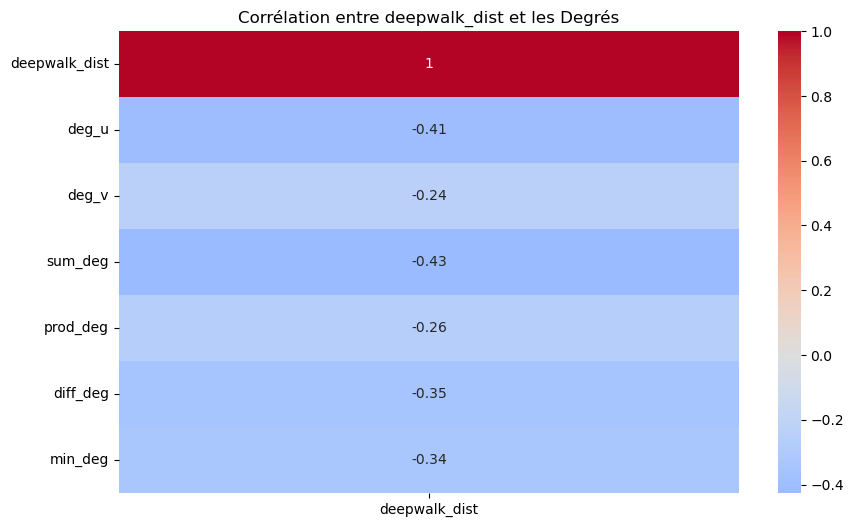


--- Running: Structure_Only on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
aa       0.664072
sp       0.111936
and_v    0.041146

--- Running: Embeddings_Only on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
deepwalk_dist         0.907399
deepwalk_cos          0.042840
n2v_homophily_dist    0.031680

--- Running: Embeddings_Only_cos on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
deepwalk_cos         0.976532
n2v_homophily_cos    0.023468

--- Running: Embeddings_Only_log on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
deepwalk_dist_log_bin         0.587061
n2v_homophily_dist_log_bin    0.412939

--- Running: Embeddings_Only_quantile on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
deepwalk_dist_quantile_bin         0.979303
n2v_homophily_dist_quantile_bin    0.020697

--- Running: Embeddings_Only_PCA on reel_Airports (Ratio: N/A) ---
Top 3 Features: 
deepwalk_dist_pca         0.905610
n2v_homophily_dist_pca    0.062458
deepwalk_cos_pca          0.016217

--- Running: In

In [4]:
# Groupes de features analysés
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u',
                      'sp', 
                      'jc', 'aa', 'cn',
                      'dc_v']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm']
#features_embeddings = ['n2v_p2_q0.5_cosine', 'n2v_p2_q0.5_dist', 'n2v_p1_q1_cosine', 'n2v_p1_q1_dist']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]
features_embeddings_cos_only = ["deepwalk_cos", "n2v_homophily_cos"]
features_embeddings_log_bin = ["deepwalk_dist_log_bin", "n2v_homophily_dist_log_bin"]
features_embeddings_quantile_bin = ["deepwalk_dist_quantile_bin", "n2v_homophily_dist_quantile_bin"]
features_embeddings_PCA = ["deepwalk_dist_pca", "deepwalk_cos_pca", "n2v_homophily_dist_pca", "n2v_homophily_cos_pca"]
#features_ground_truth = ['block_reel_u', 'block_reel_v','same_block_reel', "dist_reelle", "proba_lien_reelle"]
#features_ground_truth_same_group_only = ['same_block_reel']
#features_ground_truth_proba_only = ['proba_lien_reelle']
#features_gt_shuffled = ['group_u_shuffled', 'group_v_shuffled', 'same_group_shuffled']

experiments = {
    #"Ground_Truth_Only_SG" : features_ground_truth_same_group_only,
    #"Ground_Truth_Only": features_ground_truth,
    #"Ground_truth_Only_proba" : features_ground_truth_proba_only,
    #"Ground_Truth_Shuffled": features_gt_shuffled,
    "Structure_Only": features_structure,
    #"Structure_with_GT": features_structure + features_ground_truth,
    "Embeddings_Only": features_embeddings,
    "Embeddings_Only_cos": features_embeddings_cos_only,
    "Embeddings_Only_log": features_embeddings_log_bin,
    "Embeddings_Only_quantile": features_embeddings_quantile_bin,
    "Embeddings_Only_PCA": features_embeddings_PCA,
    "Inferred_Commu only": features_commu_inferee,
    #"Inferred_Commu_sg_only": features_commu_inferee_same_group_only,
    #"Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    #"Structure + Embeddings_log": features_structure + features_embeddings_log_bin,
    #"Structure + Embeddings_quantile": features_structure + features_embeddings_quantile_bin,
    #"Full_features": features_structure + features_commu_inferee + features_embeddings
}

all_results = []
G_name = "reel_Airports"
G_obj_Airports = load_graphml_safe("graph_library/reel_Airports.graphml")
G_obj_Blumenau = load_graphml_safe("graph_library/reel_blumenau_drug.graphml")

G_name_list = ["reel_Airports", 
               #"reel_blumenau_drug"
              ]
G_obj_list = [G_obj_Airports, G_obj_Blumenau]

for G_name, G_obj in zip(G_name_list, G_obj_list):
    
    print(f"\n" + "#"*60)
    print(f" PROCESSING GRAPH: {G_name}")
    print("#"*60)

    # 1. Chargement des données (train/eval)
    # gp.load_all_data_for_graph doit retourner les DataFrames déjà calculés
    try:
        G_train , dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    except Exception as e:
        print(f"❌ Erreur chargement data pour {G_name}: {e}")
        continue

    # On extrait le ratio SBM du nom si c'est un graphe synthétique (pour les logs)
    current_ratio = G_name.split('sbm_')[1].split('_pos')[0].replace('_', '.') if 'sbm_' in G_name else "N/A"

    # Ajoute des colonnes binning
    dataset_train = gp.apply_fixed_log_binning(dataset_train, "deepwalk_dist")
    dataset_train = gp.apply_fixed_log_binning(dataset_train, "n2v_homophily_dist")
    dataset_train = gp.apply_quantile_binning(dataset_train, "deepwalk_dist")
    dataset_train = gp.apply_quantile_binning(dataset_train, "n2v_homophily_dist")
    dataset_eval = gp.apply_fixed_log_binning(dataset_eval, "deepwalk_dist")
    dataset_eval = gp.apply_fixed_log_binning(dataset_eval, "n2v_homophily_dist")
    dataset_eval = gp.apply_quantile_binning(dataset_eval, "deepwalk_dist")
    dataset_eval = gp.apply_quantile_binning(dataset_eval, "n2v_homophily_dist")

    dataset_train = add_pca_features_from_graph(dataset_train, G_train, "deepwalk", "deepwalk", n_components=8)
    dataset_train = add_pca_features_from_graph(dataset_train, G_train, "n2v_homophily", "n2v_homophily", n_components=8)
    dataset_eval = add_pca_features_from_graph(dataset_eval, G_train, "deepwalk", "deepwalk", n_components=8)
    dataset_eval = add_pca_features_from_graph(dataset_eval, G_train, "n2v_homophily", "n2v_homophily", n_components=8)

    corr_results = check_embedding_degree_correlation(dataset_train, G_train)
    
    # 3. Lancement des expériences (Topologie, Commu, Embeddings, etc.)
    for exp_name, feat_list in experiments.items():
        # Vérification des colonnes
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" ⚠️ Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f"\n--- Running: {exp_name} on {G_name} (Ratio: {current_ratio}) ---")
        
        # Entraînement XGBoost
        # X_test et y_test ici sont issus du split interne de dataset_train (le "Test set")
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list, plot=False, 
                                                                          )

        # Feature Importance
        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 3 Features: \n{feat_imp_series.head(3).to_string()}")

        # 4. Évaluation sur le dataset_eval (Le vrai "Evaluation Set" masqué à 15%)
        X_eval_fixed = dataset_eval[feat_list] 
        y_eval_fixed = dataset_eval["target"]
        
        # Calcul des métriques sur l'évaluation
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, y_eval_fixed, "EXP_")
        
        # Stockage des résultats
        all_results.append({
            "Graph_Name": G_name,
            "Ratio_SBM": current_ratio,
            "Experiment": exp_name,
            "Test_AP": stats_df["Test_AP"].iloc[0],
            "Test_AUC": stats_df["Test_AUC-ROC"].iloc[0],
            "Eval_AP": stats_eval_df["EXP_AP"].iloc[0],
            "Eval_AUC": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Overfit_Delta_AP": stats_df["Test_AP"].iloc[0] - stats_eval_df["EXP_AP"].iloc[0],
            "Top_Feature": feat_imp_series.index[0],
            "Top_Importance": feat_imp_series.iloc[0]
        })

# --- RECAPITULATIF FINAL ---
df_compare = pd.DataFrame(all_results)
print("\n" + "="*80)
print("COMPARAISON FINALE DES PERFORMANCES")
print("="*80)
# Tri pour voir les plus gros overfits en premier
if not df_compare.empty:
    print(df_compare.sort_values(by="Overfit_Delta_AP", ascending=False).to_string(index=False))

# Sauvegarde
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "benchmark_G_reels_results.csv")
df_compare.to_csv(output_path, index=False)
print(f"\n✅ Résultats sauvegardés dans : {output_path}")

### 1.13 Execution des expériences - impact ajout de features

In [9]:
# Groupes de features analysés
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u','sp', 'jc', 'aa', 'cn', 'dc_v']
features_structure_enhanced = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u','sp', 'jc', 'aa', 'cn', 'dc_v']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_commu_inferee_enhanced = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]
features_embeddings_enhanced = []

experiments = {
    "Structure_Only": features_structure,
    #"Structure_Only_enhanced": features_structure_enhanced,
    "Embeddings_Only": features_embeddings,
    #"Embeddings_Only_enhanced": features_embeddings_enhanced,
    "Inferred_Commu only": features_commu_inferee,
    #"Inferred_Commu only_enhanced": features_commu_inferee_enhanced,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    "Structure + Inferred_Commu": features_structure + features_commu_inferee,
    "Structure + Embeddings": features_structure + features_embeddings,
    "Full_features": features_structure + features_commu_inferee + features_embeddings
    #"Full_features_enhanced ": features_structure_enhanced + features_commu_inferee_enhanced + features_embeddings_enhanced
}

all_results = []
G_obj_Blumenau = load_graphml_safe("graph_library/reel_blumenau_drug.graphml")
G_name_list = [#"reel_Airports", 
               "reel_blumenau_drug"]
G_obj_list = [#G_obj_Airports, 
              G_obj_Blumenau]

for G_name, G_obj in zip(G_name_list, G_obj_list):
    
    print(f"\n" + "#"*60)
    print(f" PROCESSING GRAPH: {G_name}")
    print("#"*60)

    G_train, dataset_train, dataset_hidden, _, _, _ = gp.load_all_data_for_graph(G_name)
    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1)
    current_ratio = "N/A" 

    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" ⚠️ Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f"\n--- Running: {exp_name} on {G_name} ---")
        
        # --- ÉTAPE OPTIMISATION (K-FOLD) ---
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=50)
        
        # --- ENTRAÎNEMENT FINAL ---
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(
            dataset_train, 
            features=feat_list, 
            parameters=Params, 
            plot=False
        )

        # Feature Importance
        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 3 Features: \n{feat_imp_series.head(3).to_string()}")

        # 4. Évaluation sur le dataset_hidden (FIXE)
        X_eval_fixed = dataset_hidden[feat_list] 
        y_eval_fixed = dataset_hidden["target"]
        
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, y_eval_fixed, "EXP_")
        
        # Stockage des résultats
        all_results.append({
            "Graph_Name": G_name,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Overfit_Delta_AP": stats_df["Test_AP"].iloc[0] - stats_eval_df["EXP_AP"].iloc[0],
            "Top_Feature": feat_imp_series.index[0],
            "Top_Importance": feat_imp_series.iloc[0]
        })

# --- RECAPITULATIF FINAL ---
df_compare = pd.DataFrame(all_results)
print("\n" + "="*90)
print("COMPARAISON FINALE : GRAPHES RÉELS + OPTIMISATION")
print("="*90)
if not df_compare.empty:
    # Tri par AP_eval pour voir quelle expérience généralise le mieux
    print(df_compare.sort_values(by=["Graph_Name", "AP_eval"], ascending=[True, False]).to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

# Sauvegarde
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "benchmark_G_reels_results.csv")
df_compare.to_csv(output_path, index=False)
print(f"\n✅ Résultats sauvegardés dans : {output_path}")

✅ Graphe chargé : 75 nœuds et 181 liens.

############################################################
 PROCESSING GRAPH: reel_blumenau_drug
############################################################
SHAP Analysis introuvable pour reel_blumenau_drug.
[K-FOLD] Préparation de 1 folds en parallèle...
--- Démarrage Parallèle Fold 1 ---
Graphe original: 109 liens
Graphe d'entraînement: 92 liens
Liens cachés pour le test: 17

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 2):  32%|███▏      | 8/25 [00:00<00:00, 55.07it/s]

Generating walks (CPU: 3):  28%|██▊       | 7/25 [00:00<00:00, 69.69it/s]


Generating walks (CPU: 1):  72%|███████▏  | 18/25 [00:00<00:00, 56.47it/s]

Generating walks (CPU: 3):  56%|█████▌    | 14/25 [00:00<00:00, 63.33it/s]


Generating walks (CPU: 2):  80%|████████  | 20/25 [00:00<00:00, 44.68it/s]


Generating walks (CPU: 1):  96%|█████████▌| 24/25 [00:00<00:00, 49.37it/s]

Generating walks (CPU: 2): 100%|██████████| 25/25 [00:00<00:00, 48.56it/s]



Generating walks (CPU: 4): 100%|██████████| 25/25 [00:00<00:00, 54.91it/s]


Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 1):  28%|██▊       | 7/25 [00:00<00:00, 68.21it/s]A


Generating walks (CPU: 2):  28%|██▊       | 7/25 [00:00<00:00, 49.09it/s]

Generating walks (CPU: 3):  28%|██▊       | 7/25 [00:00<00:00, 49.58it/s]


Generating walks (CPU: 4):  40%|████      | 10/25 [00:00<00:00, 41.86it/s]

Generating walks (CPU: 1):  56%|█████▌    | 14/25 [00:00<00:00, 45.83it/s]


Generating walks (CPU: 4):  76%|███████▌  | 19/25 [00:00<00:00, 54.35it/s]

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:00<00:00, 52.05it/s]


Generating walks (CPU: 1): 100%|██████████| 25/25 [00:00<00:00, 46.24it/s]


Entraînement du modèle Skip-gram...

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


...


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.812653      0.0 0.113735   0.044094
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    32 0.850459      0.0 0.182074   0.001790
    47 0.846378      0.0 0.174896   0.009851
    34 0.845663      0.0 0.176647   0.006586
    25 0.845459      0.0 0.173397   0.040181
    20 0.843878      0.0 0.180128   0.060967
    41 0.843036      0.0 0.176123  -0.029022
    21 0.842755      0.0 0.164933   0.059667
    23 0.841862      0.0 0.181800   0.065404
    18 0.841862      0.0 0.175936   0.046892
    13 0.840995      0.0 0.165775   0.015753
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u    0.198689
pr_u    0.138436
sp      0.090541

--- Running: Structure + Embeddings on reel_blumenau_drug ---


[I 2026-03-13 10:31:07,815] Trial 1 finished with value: 0.8124744897959184 and parameters: {'learning_rate': 0.018542505409699928, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.8221482756731217, 'colsample_bytree': 0.9869150371197659, 'reg_alpha': 0.19957060716347727, 'reg_lambda': 0.00845385027215355}. Best is trial 0 with value: 0.827984693877551.
[I 2026-03-13 10:31:07,944] Trial 2 finished with value: 0.8240561224489795 and parameters: {'learning_rate': 0.010797266186106557, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.9149564686253382, 'colsample_bytree': 0.612104713812636, 'reg_alpha': 0.006763380020817006, 'reg_lambda': 0.001994188770918165}. Best is trial 0 with value: 0.827984693877551.
[I 2026-03-13 10:31:08,006] Trial 3 finished with value: 0.5 and parameters: {'learning_rate': 0.020619356580745964, 'max_depth': 3, 'min_child_weight': 11, 'subsample': 0.7219640165490067, 'colsample_bytree': 0.9929029182021346, 'reg_alpha': 0.00938136929519445, 'reg_lambda':


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.827985      0.0 0.156326   0.061289
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    17 0.854668      0.0 0.197402   0.014017
    42 0.852321      0.0 0.190228   0.013769
    43 0.851786      0.0 0.195261   0.032643
    24 0.851403      0.0 0.170472   0.021780
    18 0.847806      0.0 0.174200   0.025377
    47 0.847143      0.0 0.219126  -0.027074
    26 0.845051      0.0 0.161317   0.031420
    12 0.843827      0.0 0.214544  -0.027218
    21 0.843724      0.0 0.194659  -0.006008
    13 0.843673      0.0 0.183732   0.058057
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u                  0.171458
n2v_homophily_dist    0.093952
pr_u                  0.082863

--- Running: Full_features on reel_blumenau_drug ---


[I 2026-03-13 10:31:12,840] Trial 1 finished with value: 0.8056632653061224 and parameters: {'learning_rate': 0.0294483206064202, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.9092422756240988, 'colsample_bytree': 0.8260268038718971, 'reg_alpha': 0.006667929908630937, 'reg_lambda': 1.5571753201183651}. Best is trial 0 with value: 0.8075.
[I 2026-03-13 10:31:12,926] Trial 2 finished with value: 0.5 and parameters: {'learning_rate': 0.08064760154365817, 'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.7425772466716828, 'colsample_bytree': 0.6643621877634194, 'reg_alpha': 0.3114130305615163, 'reg_lambda': 4.584583362882971}. Best is trial 0 with value: 0.8075.
[I 2026-03-13 10:31:13,016] Trial 3 finished with value: 0.8520408163265306 and parameters: {'learning_rate': 0.028303645815488512, 'max_depth': 9, 'min_child_weight': 4, 'subsample': 0.6217903869033676, 'colsample_bytree': 0.9513701980566367, 'reg_alpha': 0.014332564985032875, 'reg_lambda': 0.01498628880115265}. Best 


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0   0.8075      0.0 0.136428   0.082811
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    16 0.854184      0.0 0.193269   0.016059
    19 0.853673      0.0 0.198693   0.023489
    22 0.853673      0.0 0.192434   0.010340
    31 0.852296      0.0 0.199220   0.013967
    32 0.852092      0.0 0.202062   0.010538
    38 0.852041      0.0 0.159300   0.097786
     3 0.852041      0.0 0.188877   0.011108
    27 0.851888      0.0 0.152154   0.106590
    34 0.851658      0.0 0.198569   0.054224
    21 0.851480      0.0 0.196148   0.022742
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 3 Features: 
dc_u                  0.116950
n2v_homophily_dist    0.098807
pr_u                  0.088358

COMPARAISON FINALE : GRAPHES RÉELS + OPTIMISATION
        Graph_Name  

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

Graphique sauvegardé ici : outputs/plots/artificial_graphs_comparaison_AUC_eval_per_SBM_ratio.png


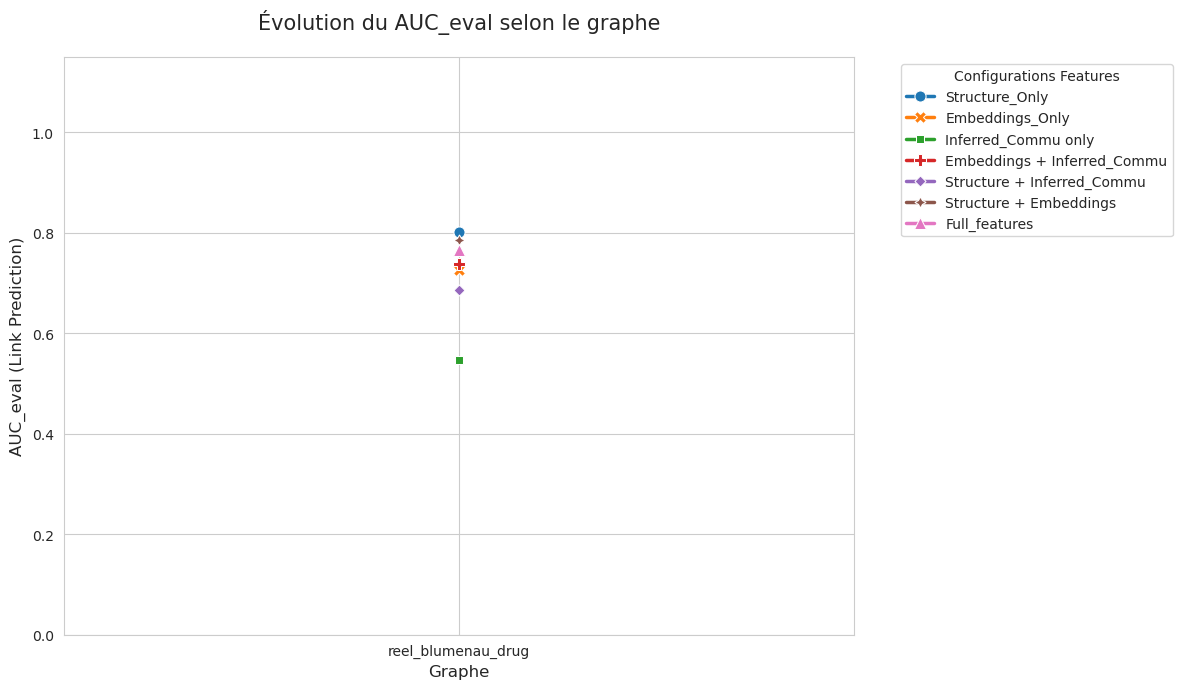

Entraînement du modèle Skip-gram...
Préparation des listes de paires...
Extraction parallèle sur 187 paires (n_jobs=-1)...
DataFrame créé avec succès : 187 lignes.
Préparation des listes de paires...
Extraction parallèle sur 728 paires (n_jobs=-1)...
DataFrame créé avec succès : 728 lignes.


In [10]:
def plot_f1_comparison(df_results, metric="F1-Score"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Graph_Name", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le graphe", fontsize=15, pad=20)
    plt.xlabel("Graphe", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 1.15) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"artificial_graphs_comparaison_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

plot_f1_comparison(df_compare, metric="AUC_eval" )

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [72]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

Taux de liens réels (p) au sein d'un bloc :
Sans voisins communs : 0.9848
Avec voisins communs : 0.9791
--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
Taux réel quand CN = 0 : 0.9420
Taux réel quand CN > 0 : 0.8966
--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
    mean  count
sp             
1  1.000   2888
2  0.875    570
3  0.857      7

Taux réel quand SP = 0 (aucun chemin) : nan
Taux réel quand SP > 0 (chemin existe) : 0.8974

============= DEEP DIVE PERFORMANCE : GT Only ==============
Nombre total de paires : 7700
------------------------------------------------------------
VRAIS POSITIFS (TP) : 708
  ├─ Intra-bloc : 708 | Inter-bloc : 0
  └─ Dont déjà connus (SP=1) : 603 (85.2%)
  └─ Trouvés par intelligence (SP!=1) : 105
------------------------------------------------------------
FAUX POSITIFS (FP) : 10
  ├─ Intra-bloc : 10 (Confusion même bloc)
  ├─ Inter-bloc : 0 (Erreur sur

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_11338/2678378530.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()


### 1.4 plots des AP curves

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

ValueError: continuous-multioutput format is not supported

<Figure size 1000x700 with 0 Axes>

### 1.5 Analyse de variance de probas prédites

In [104]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)


=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===
                          Type       Modèle  Variance  Valeurs Uniques  Moyenne
  Intra-Bloc (Même communauté) Ground Truth     0.001              570    0.977
  Intra-Bloc (Même communauté)    Structure     0.088              679    0.104
Inter-Bloc (Communautés diff.) Ground Truth     0.000             5705    0.003
Inter-Bloc (Communautés diff.)    Structure     0.077             4654    0.089


### 1.5 Analyse des communautés inférées

In [99]:
def compute_agreement_ratio(X_test, dataset, algo_col='same_infomap'):
    """
    Calcule le pourcentage de paires où l'inférence est d'accord avec la GT.
    """
    # 1. On récupère la vérité terrain
    y_true = dataset.loc[X_test.index, 'same_block_reel']
    y_inf  = X_test[algo_col]
    
    # 2. On compare
    agreement = (y_true == y_inf).mean()
    
    print(f"Ratio d'accord entre {algo_col} et la réalité : {agreement:.2%}")
    
    # Détail pour ton chercheur :
    # Combien de fois l'algorithme a vu une communauté là où il n'y en a pas (Faux Positifs de structure)
    over_detection = ((y_inf == 1) & (y_true == 0)).sum()
    print(f"  └─ Paires vues 'ensemble' par erreur : {over_detection}")
    
    return agreement

def count_inferred_communities(dataset, algo_prefix='infomap'):
    """
    Compte le nombre de clusters uniques trouvés par un algorithme.
    Ex: algo_prefix='infomap' ira chercher 'infomap_u' et 'infomap_v'.
    """
    col_u = f"{algo_prefix}_u"
    col_v = f"{algo_prefix}_v"
    
    if col_u in X_test.columns and col_v in X_test.columns:
        # On combine les deux colonnes et on compte les valeurs uniques
        all_commus = pd.concat([X_test[col_u], X_test[col_v]])
        n_unique = all_commus.nunique()
        print(f"Nombre de communautés uniques ({algo_prefix}) : {n_unique}")
        return n_unique
    else:
        print(f"Colonnes pour {algo_prefix} introuvables.")
        return None

# Utilisation
n_infomap = count_inferred_communities(dataset, 'infomap')
ratio = compute_agreement_ratio(X_test_s, dataset, 'same_infomap')

Nombre de communautés uniques (infomap) : 100
Ratio d'accord entre same_infomap et la réalité : 100.00%
  └─ Paires vues 'ensemble' par erreur : 0


### 1.6 Exploration visuelle des positions et catégories

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


NameError: name 'PROJECT_ROOT' is not defined

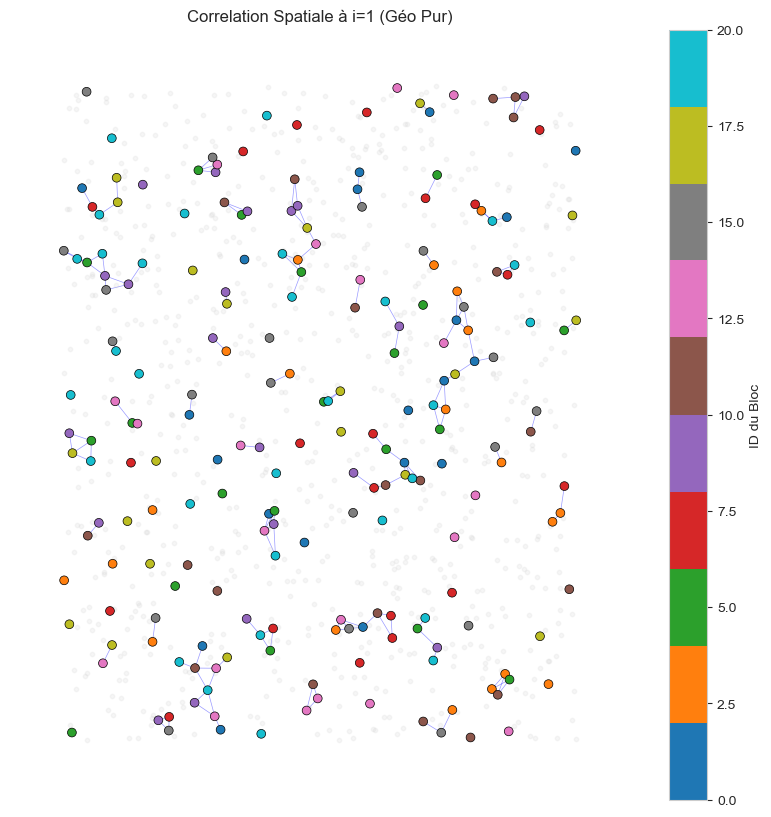

In [81]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Evaluation perfs sur echantillon plus large - OBSOLETE

In [79]:
def generate_extended_eval_data(G, initial_pairs_df, expansion_factor=50, concat = True):
    nodes_list = list(G.nodes())
    num_initial = len(initial_pairs_df)
    target_extra = num_initial * expansion_factor

    existing_pairs = set()
    for u, v in zip(initial_pairs_df['u'], initial_pairs_df['v']):
        existing_pairs.add(tuple(sorted((u, v))))

    extra_pairs_list = []
    current_extra_set = set() 
    
    while len(extra_pairs_list) < target_extra:
        batch_size = min(target_extra - len(extra_pairs_list), 50000)
        random_u = np.random.choice(nodes_list, size=batch_size)
        random_v = np.random.choice(nodes_list, size=batch_size)
        
        for u, v in zip(random_u, random_v):
            if u == v:
                continue
            
            pair = tuple(sorted((u, v)))
            
            if pair not in existing_pairs and pair not in current_extra_set:
                current_extra_set.add(pair)
                extra_pairs_list.append({'u': u, 'v': v, 'target': 0})
            
            if len(extra_pairs_list) >= target_extra:
                break

    extra_df = pd.DataFrame(extra_pairs_list)
    
    if concat: 
        full_df = pd.concat([initial_pairs_df, extra_df], ignore_index=True)
    else:
        full_df = extra_df

    full_df = add_ground_truth_groups(full_df, G)
    
    return full_df

def run_scaling_evaluation(G, base_dataset, experiments_dict, eval_data, factors=[10, 20, 30, 40, 50]):
    all_results = []
    
    for factor in factors:
        print(f"\n" + "="*50)
        print(f" TEST AVEC EXPANSION FACTOR : {factor}")
        print("="*50)
        
        # 1. Génération du dataset d'entraînement étendu
        extended_train_data = generate_extended_eval_data(G, base_dataset, expansion_factor=factor, concat=True)
        
        for exp_name, feat_list in experiments_dict.items():
            print(f"\n🔹 Expérience : {exp_name}")
            
            # 3. Entraînement et Test classique (sur le set étendu)
            stats_train, model, X_test_base, _, y_test_base, _ = gp.train_and_eval_xgboost(extended_train_data, features=feat_list)
            
            # 4. Evaluation
            X_eval_robust = pd.concat([eval_data[feat_list], X_test_base[feat_list]], ignore_index=True)
            y_eval_robust = pd.concat([eval_data["target"], y_test_base], ignore_index=True)
            
            eval_stats = gp.evaluate_model_performance(model, X_eval_robust, y_eval_robust)
            
            # 5. Stockage des résultats
            all_results.append({
                "Factor": factor,
                "Experiment": exp_name,
                "AUC-PR_Test": stats_train["AUC-PR"].iloc[0],
                "AUC-ROC_Eval": eval_stats["AUC-ROC"].iloc[0],
                "F1_Eval": eval_stats["F1-Score"].iloc[0]
            })
            
    return pd.DataFrame(all_results)

In [80]:
G_name = "artificial_graph_sbm_0_00_pos_1_00"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

dataset = dataset_raw[["u", "v", "target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_stress_test = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

experiments = {
    "Ground_Truth_Only_SG": ['same_group'],
    "Ground_Truth_Full": ['group_u', 'group_v', 'same_group'],
}

print(f"Lancement de l'évaluation multi-expériences...")
df_final_results = run_scaling_evaluation(
    G=G, 
    base_dataset=dataset, 
    experiments_dict=experiments, 
    eval_data=eval_stress_test, 
    factors= [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
)

print("\n Analyse terminée.")
print(df_final_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"ANALYSE_Scaling_Full_{G_name}.csv")
df_final_results.to_csv(save_path, index=False)
print(f"Résultats sauvegardés sous : {save_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3500 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib

--- TEST AVEC EXPANSION FACTOR : 0 ---
Modèle A (Same Group Only)...

 RÉSULTATS
[{'F1-Score': 0.9843304843304843, 'AUC-ROC': 0.9844839235811291, 'AP': 0.9833514976974892, 'AUC-PR': 0.9916351580908542}]

 RÉ

In [67]:
import os

# 1. Création du dossier de destination s'il n'existe pas
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)

# 2. Définition du nom du fichier
file_name = f"ANALYSE_EtudeFacteurRatioLiensNonLiens_{G_name}.csv"
file_path = os.path.join(output_dir, file_name)

# 3. Sauvegarde du DataFrame
df_final_results.to_csv(file_path, index=False)

print(f"✅ Dataset sauvegardé avec succès dans : {file_path}")

✅ Dataset sauvegardé avec succès dans : outputs/results/ANALYSE_EtudeFacteurRatioLiensNonLiens_artificial_graph_sbm_1_00_pos_0_00.csv


In [37]:
G_name = "artificial_graph_sbm_0_60_pos_0_40"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_sg = ['same_group']

dataset = dataset_raw[["u", "v","target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_dataset = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

dataset_extended_50 = generate_extended_eval_data(G, df_initial, expansion_factor=50, concat=False)
dataset_extended_10 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)
dataset_extended_20 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)

results =[]
print("DATASET DE BASE, SAME_GROUP ONLY : ")
stats_df, model_a, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth_sg)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })
X_eval = pd.concat([eval_dataset[features_ground_truth_sg], X_test[features_ground_truth_sg]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_a,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET DE BASE, W GROUPS ID : ")
stats_df, model_b, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

X_eval = pd.concat([eval_dataset[features_ground_truth], X_test[features_ground_truth]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_b,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET EXTENDED*50, W GROUPS ID : ")
stats_df, model_c, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset_e, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

"""
gp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])
"""

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3495 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_60_pos_0_40
 Taille : 6990 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
DATASET DE BASE, SAME_GROUP ONLY : 

 RÉSULTATS
[{'F1-Score': 0.5784313725490197, 'AUC-ROC': 0.7020746938976217, 'AP': 0.7099103007031315, 'AUC-PR': 0.8519782405744738}]

 RÉSULTATS D'ÉVALUATION
-------------

'\ngp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])\n'

## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [5]:
all_summaries = []

for i in np.arange(0, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


SHAP Analysis introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_25_pos_0_75.
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_50_pos_0_50.
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_75_pos_0_25.
SHAP Analysis introuvable pour artificial_graph_sbmv2_1_00_pos_0_00.


### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_mean_shap.png


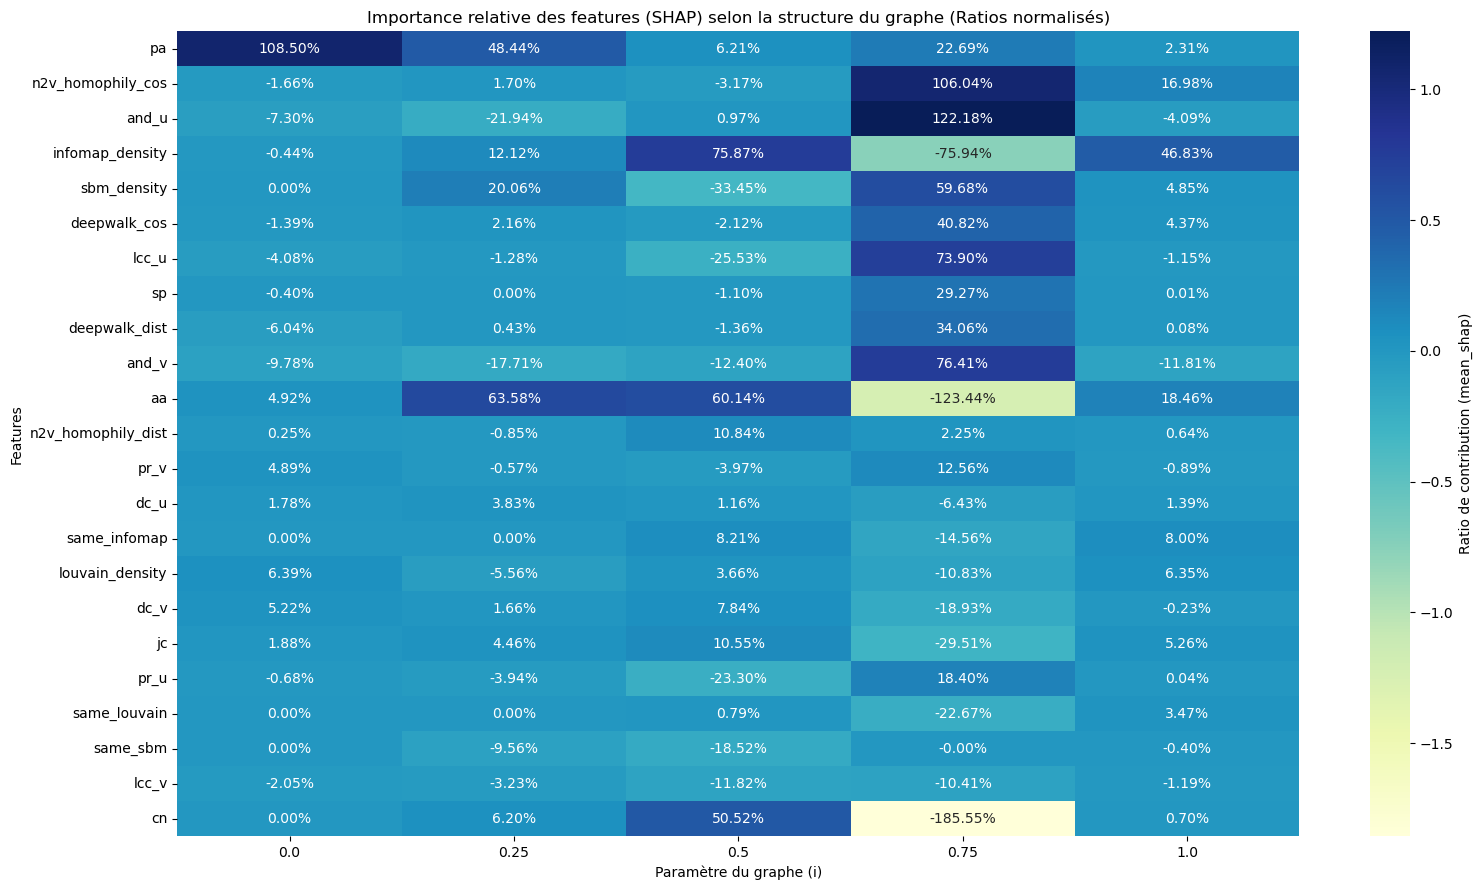

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr

'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_abs_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, 
                annot=True,       
                fmt=fmt_type,        
                cmap="YlGnBu",    
                cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_shap", as_ratio=True)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_0_00_pos_1_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_train_artificial_graph_sbm_0_00_pos_1_00
 Taille : 32725 lignes, 29 colonnes.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_eval_artificial_graph_sbm_0_00_pos_1_00
 Taille : 26775 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
SHAP Analysis introuvable pour artificial_gra

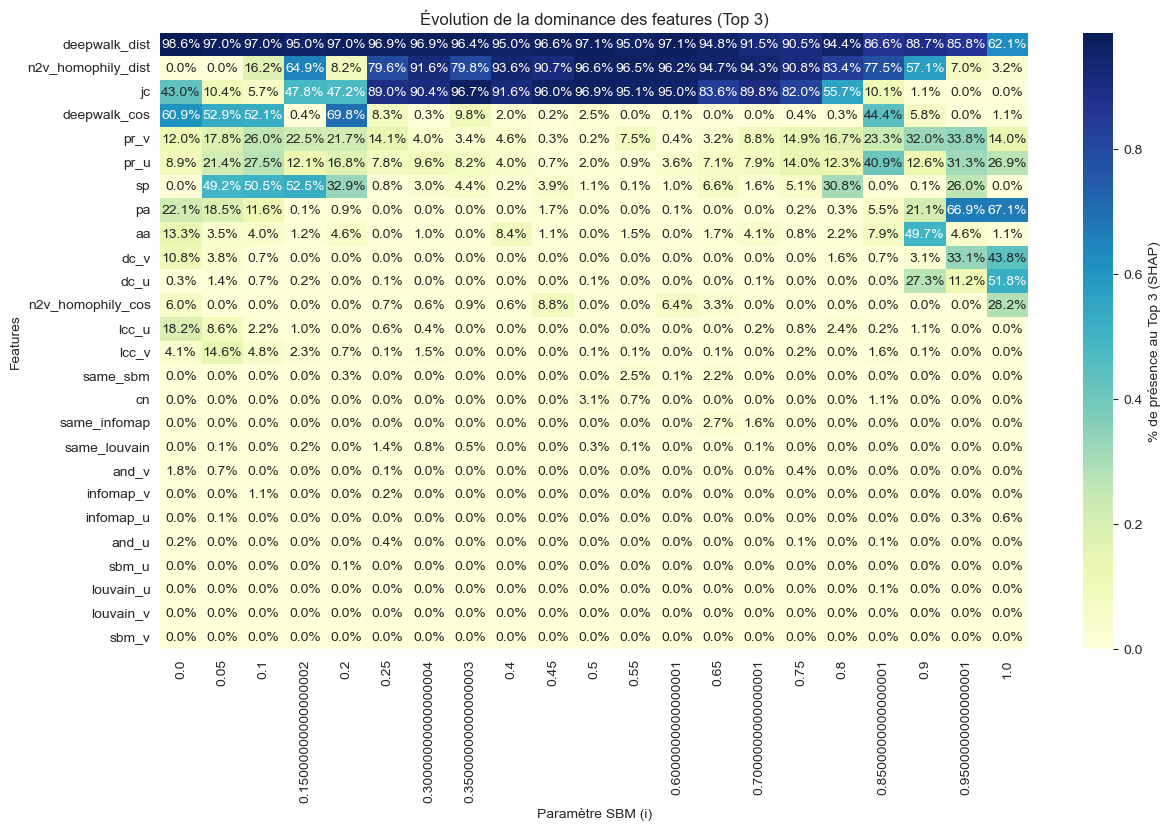

In [66]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

## 3 - Exploration des features et groupes de features

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


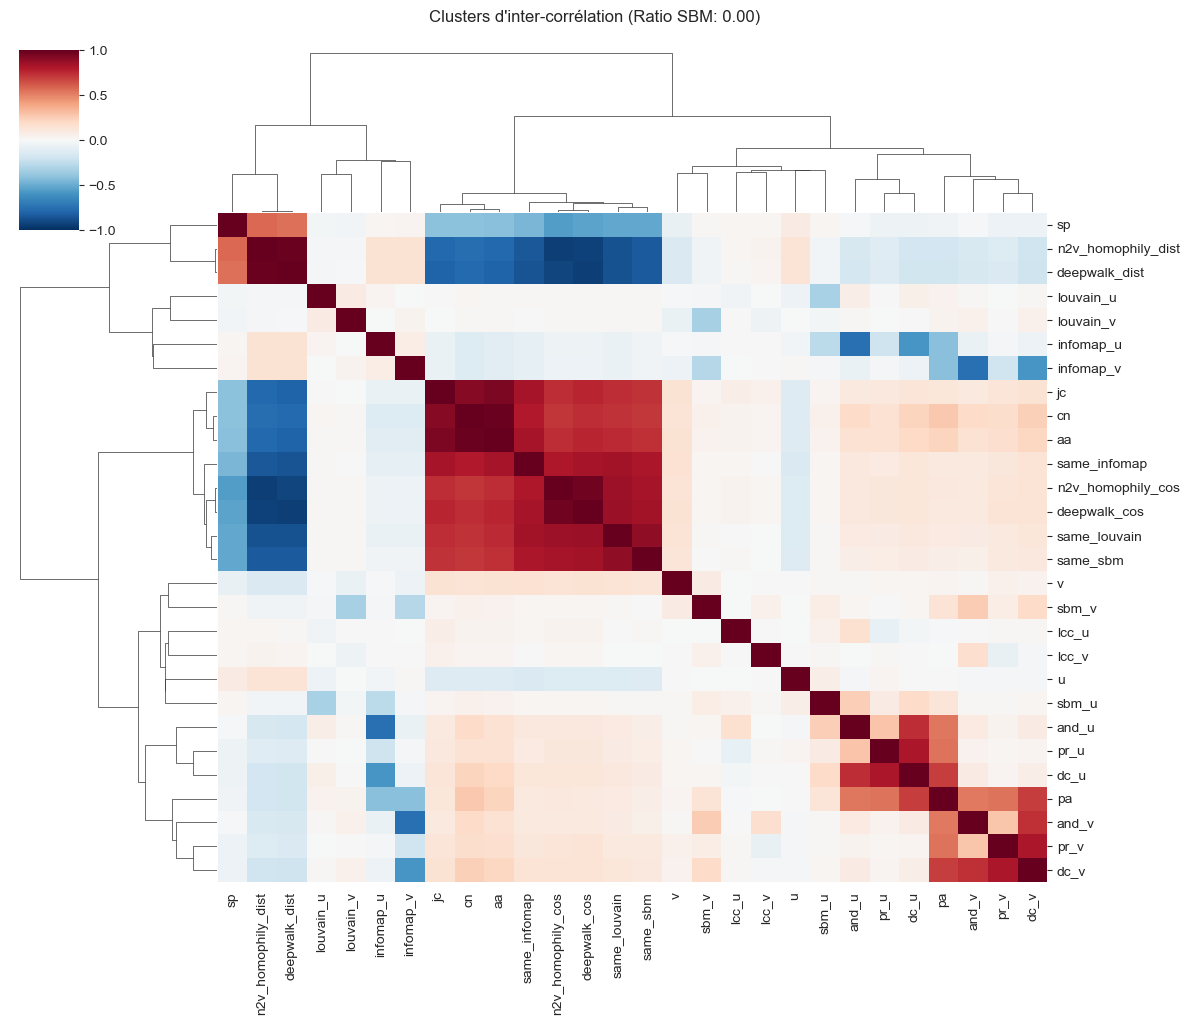

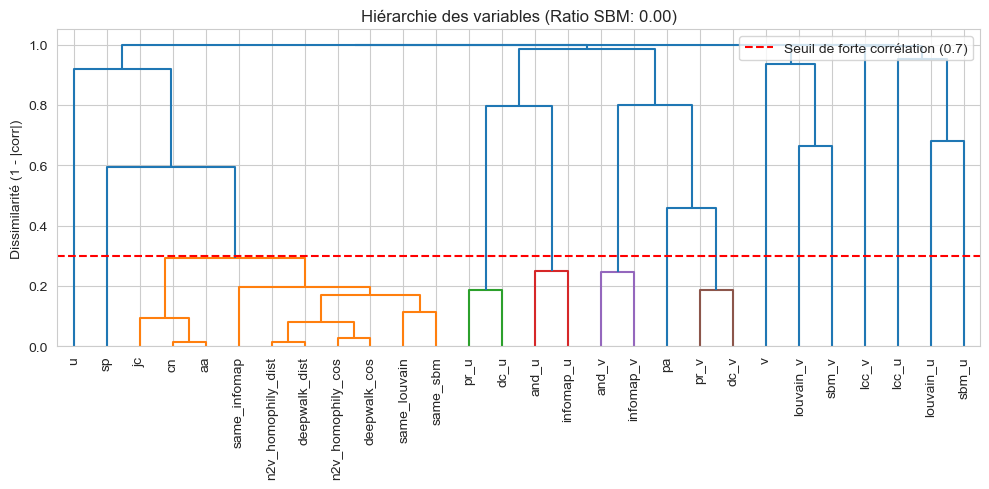

SHAP Analysis introuvable pour artificial_graph_sbm_0_25_pos_0_75.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_25.png


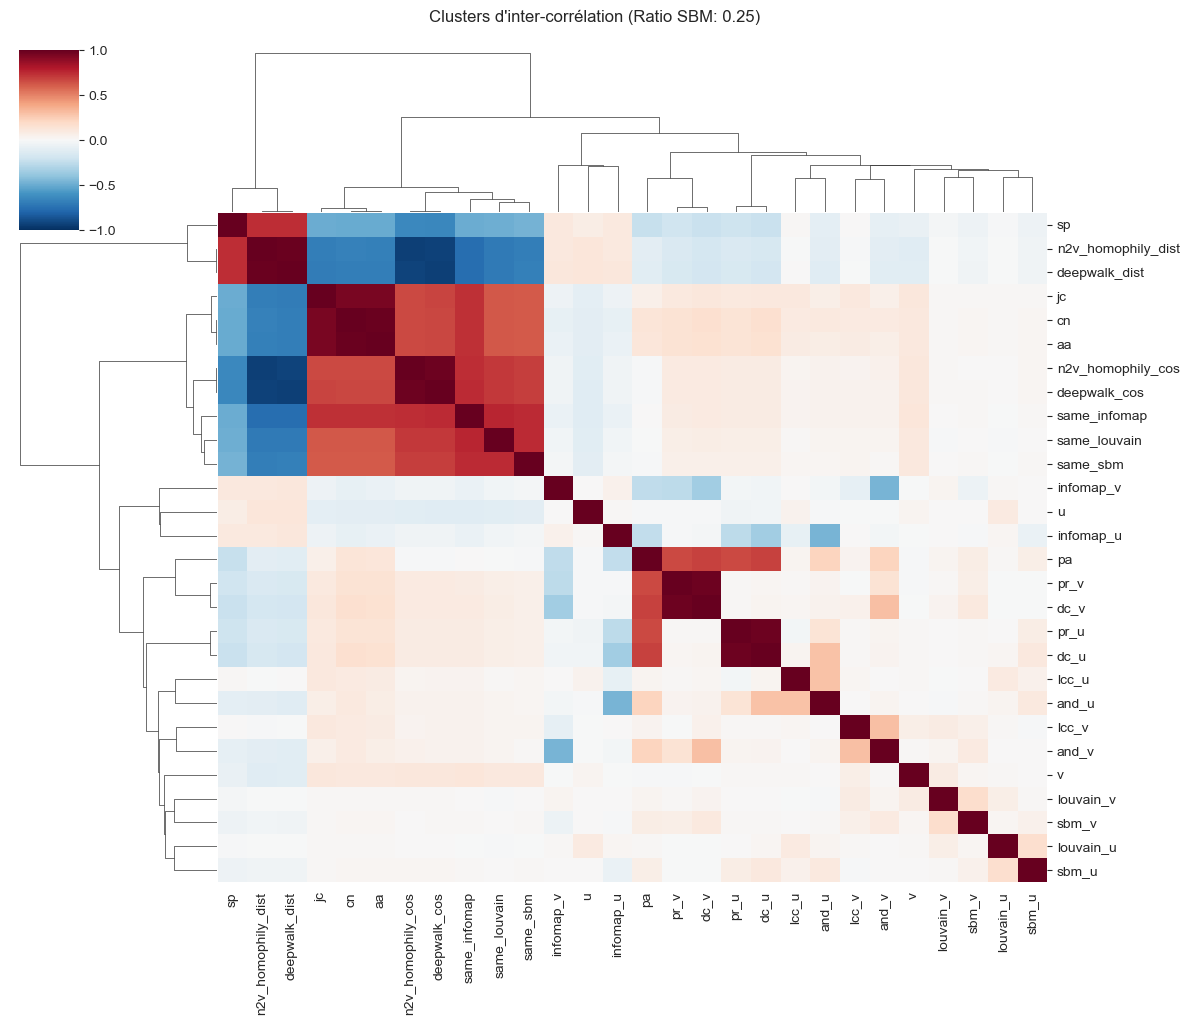

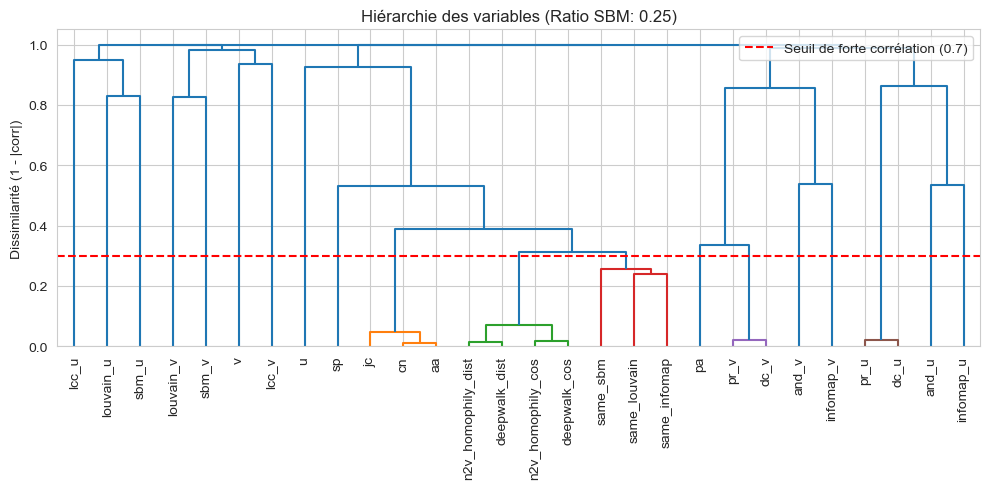

SHAP Analysis introuvable pour artificial_graph_sbm_0_50_pos_0_50.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_50.png


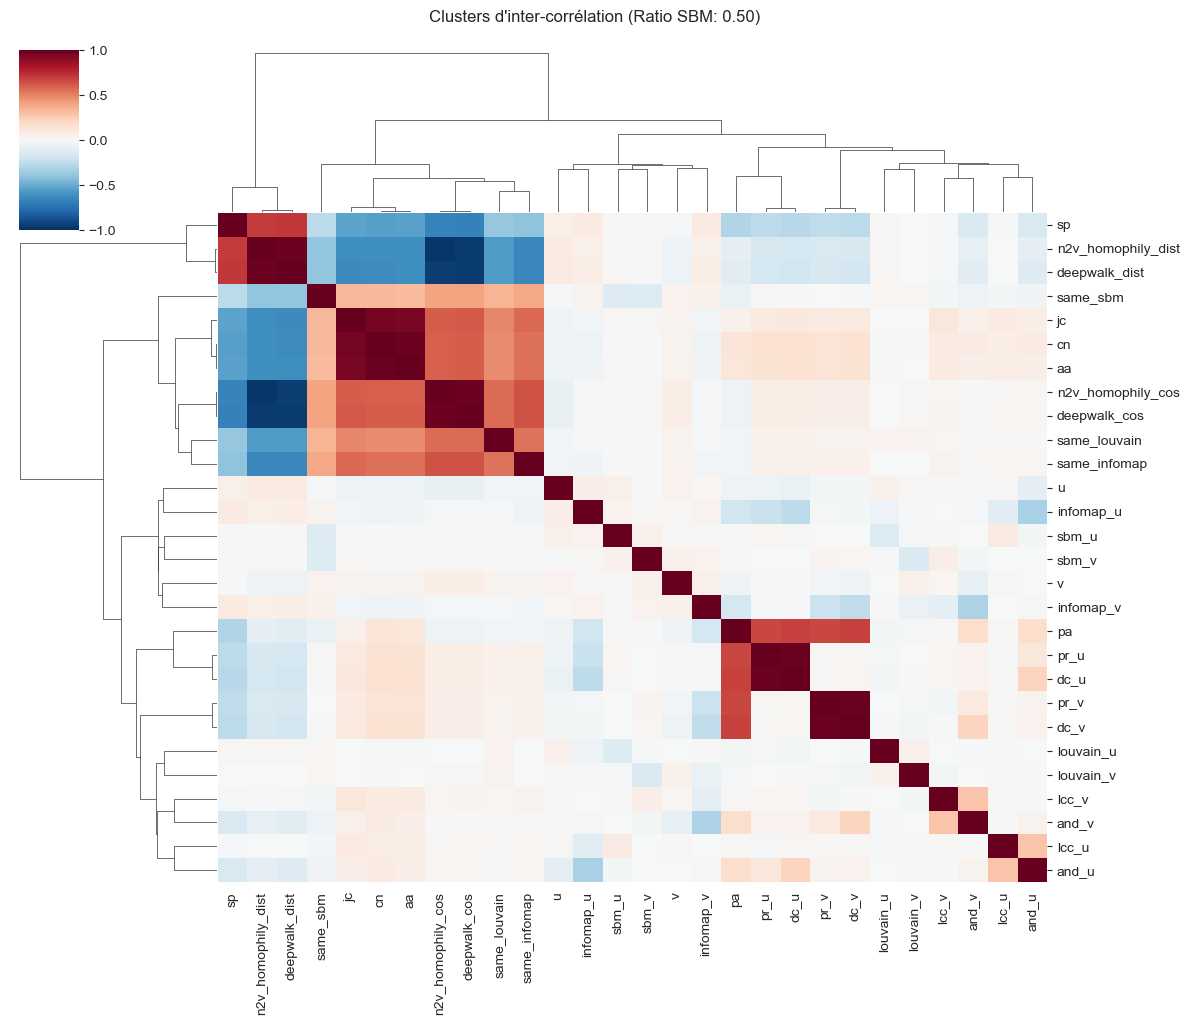

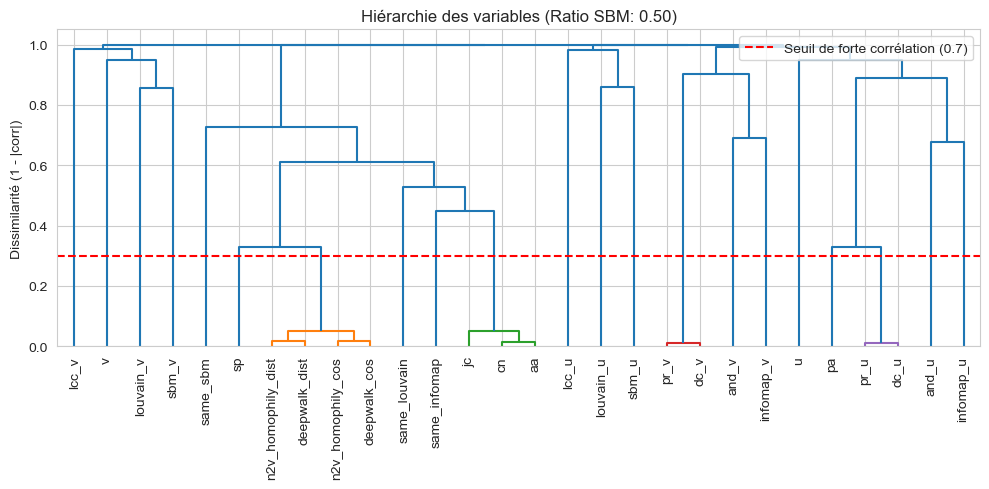

SHAP Analysis introuvable pour artificial_graph_sbm_0_75_pos_0_25.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_75.png


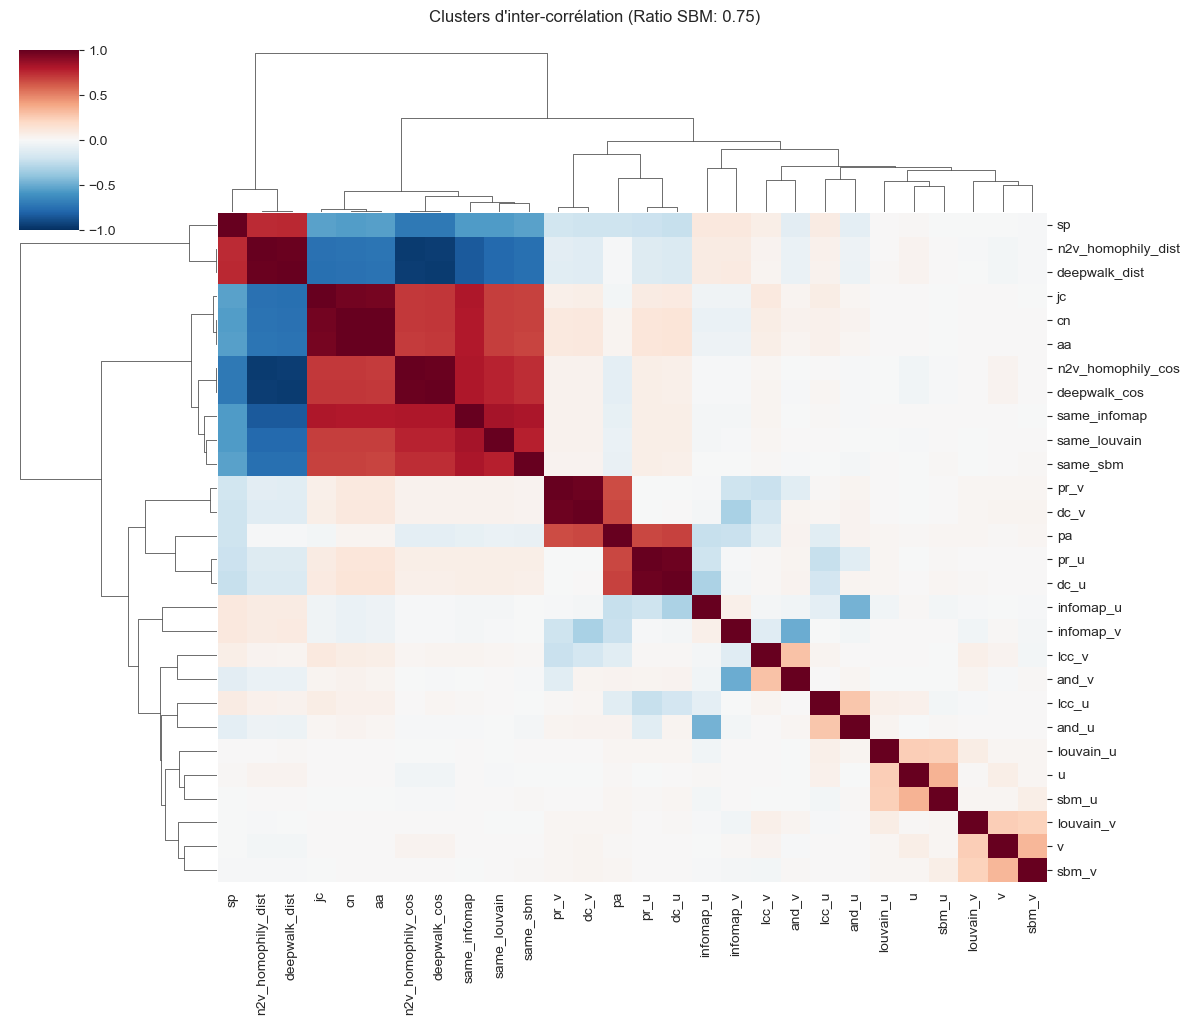

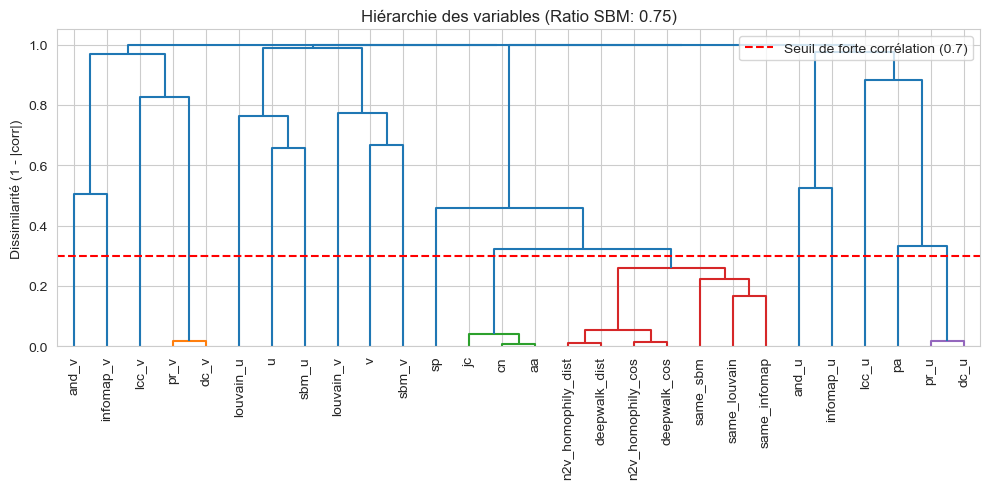

SHAP Analysis introuvable pour artificial_graph_sbm_1_00_pos_0_00.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_1_00.png


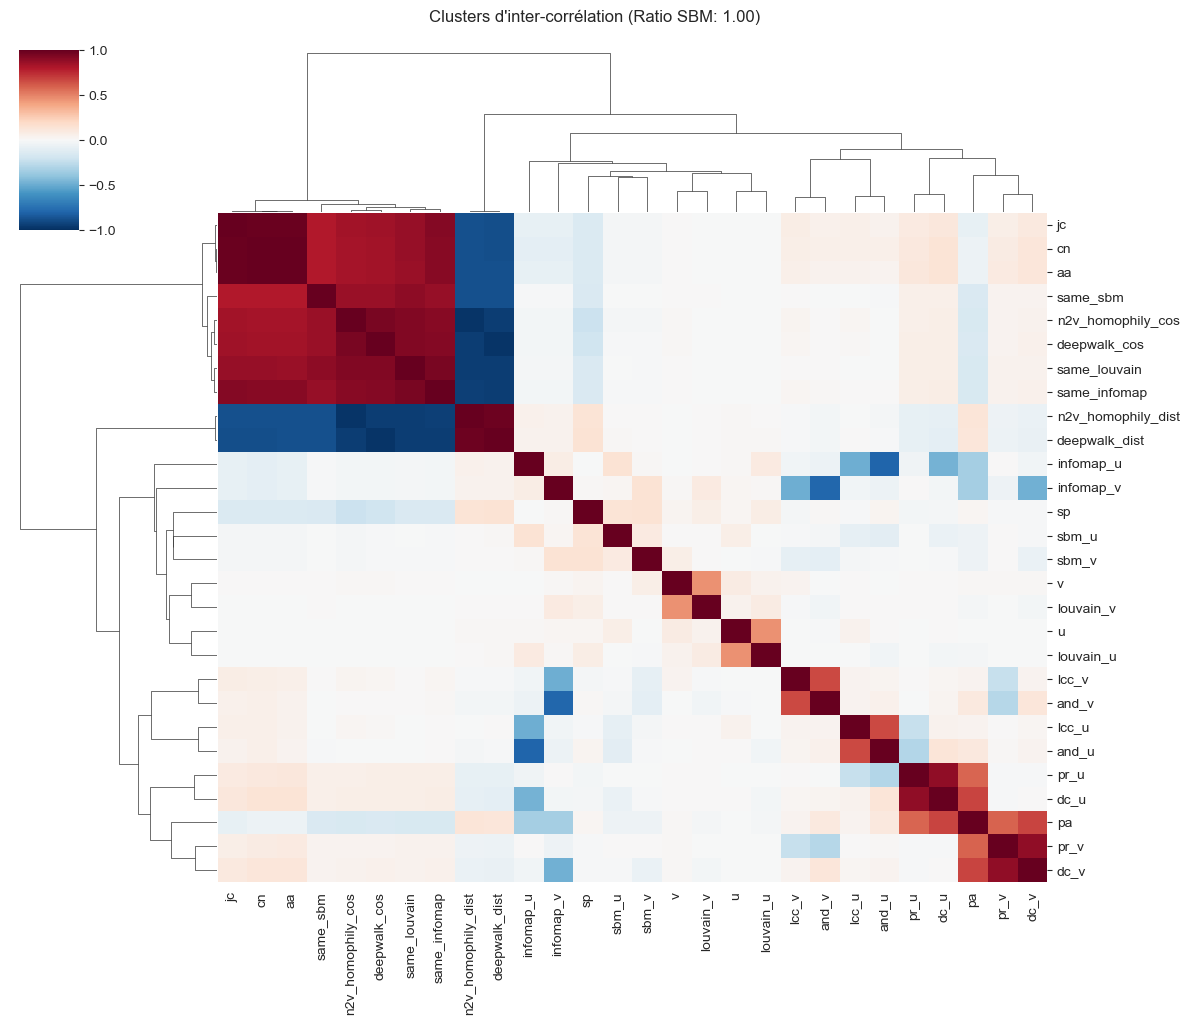

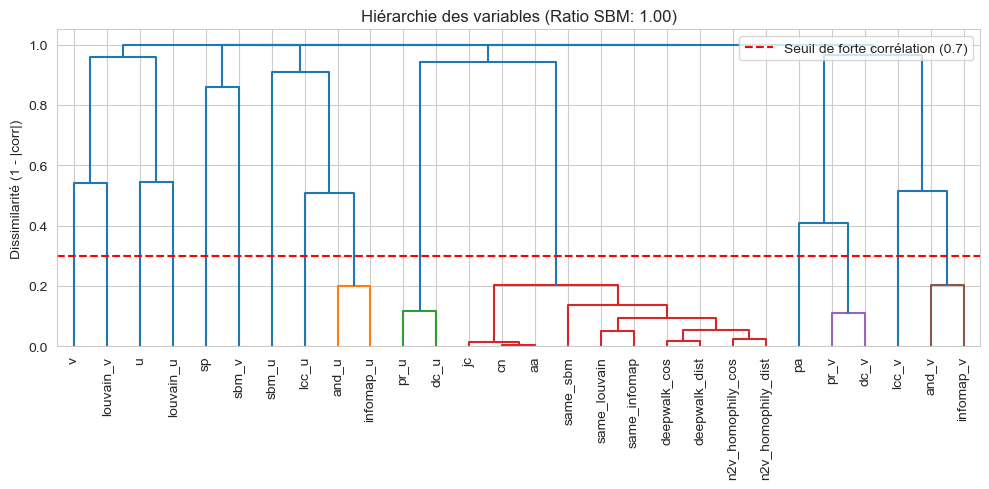

In [82]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_u', 'sbm_v', 'same_sbm', 'infomap_u', 'infomap_v', 'same_infomap', "louvain_u", "louvain_v", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = np.arange(0, 1.05, 0.25) # On réduit le pas pour les plots de clusters

for i in ratios:
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]
    
    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()


    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    # Distance = 1 - valeur absolue de la corrélation (pour regrouper corr+ et corr-)
    dissimilarity = 1 - np.abs(corr_matrix)
    # squareform pour transformer en vecteur de distance
    Z = hierarchy.linkage(squareform(dissimilarity), method='complete')
    
    hierarchy.dendrogram(Z, labels=features, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4 - Other

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


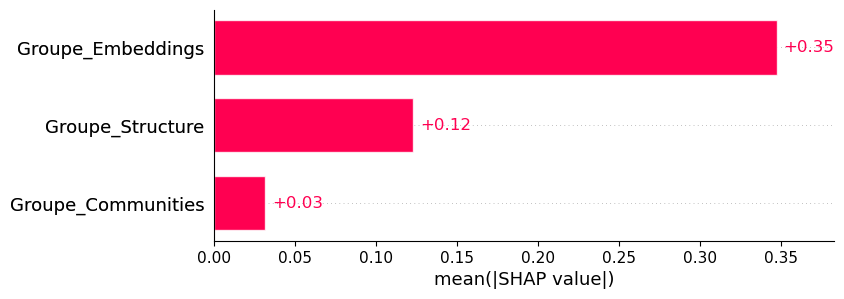


--- SHAP Bar Plot (Absolute) ---


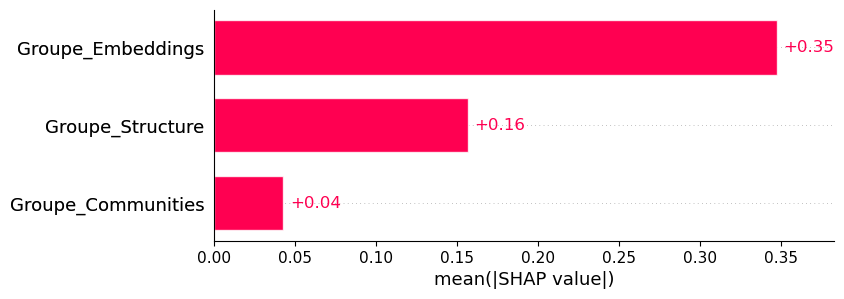


--- SHAP Custom Analysis ---


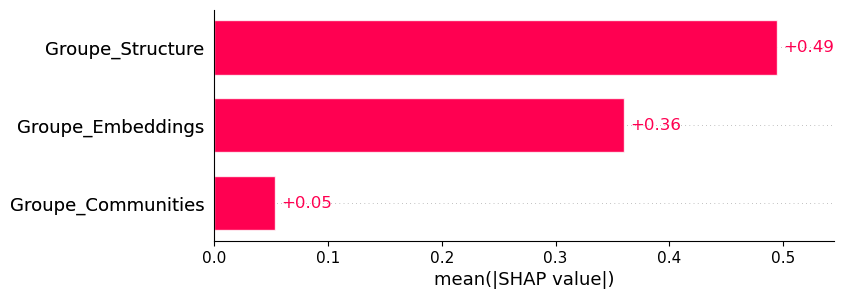


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


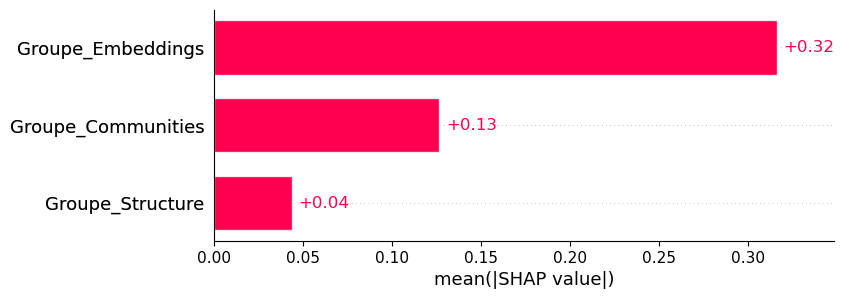


--- SHAP Bar Plot (Absolute) ---


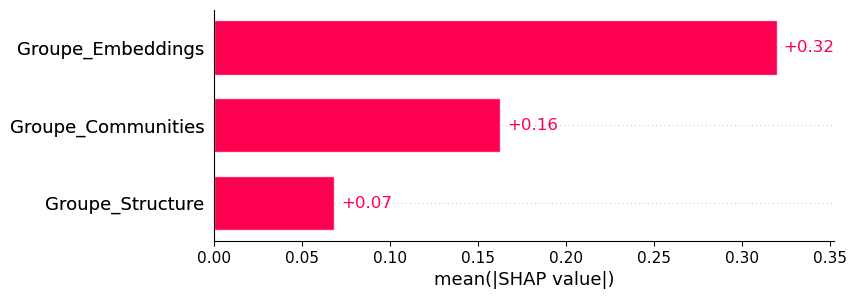


--- SHAP Custom Analysis ---


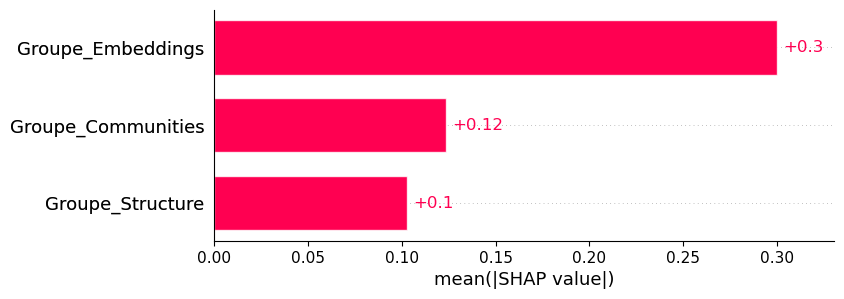


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
def xgboost_shap_pipeline(dataset, name):
    exclude = ['u', 'v', 'target', 'label']
    features = [col for col in dataset.columns if col not in exclude]
    
    results, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset, features=features)

    data_to_save = {
        "results": results,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "y_test": y_test,
        "y_train": y_train
    }

    print("Sauvegarde des données XGBoost (model,X1yTest et Train)")
    gp.loadsave_data_joblib(data=data_to_save,filename=f"xgboost_data_{name}.joblib", mode="save")

    print("\n RÉSULTATS")
    print(results.to_string(index=False))

    print("\n Shapley va ! Lu.")

    shap_explanation = gp.analyze_with_shap(model, X_test)
    print("Sauvegarde de l'analyse SHAP")
    gp.loadsave_data_joblib(data=shap_explanation, filename = f"shap_explainer_{name}.joblib", mode="save")

xgboost_shap_pipeline(dataset_sbm_1_true_groups, "TEST_W_REAL_GROUPS_SBM_1")
xgboost_shap_pipeline(dataset_sbm_0_5_true_groups, "TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


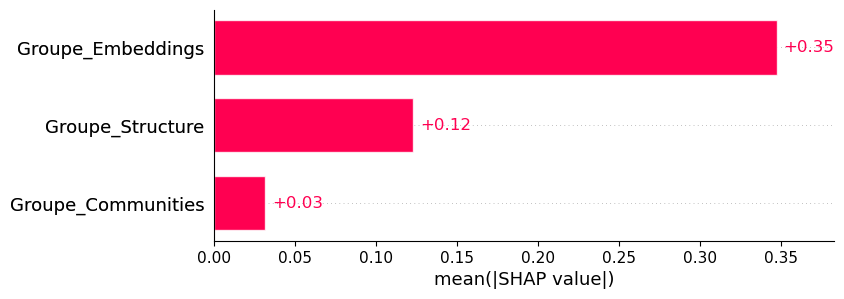


--- SHAP Bar Plot (Absolute) ---


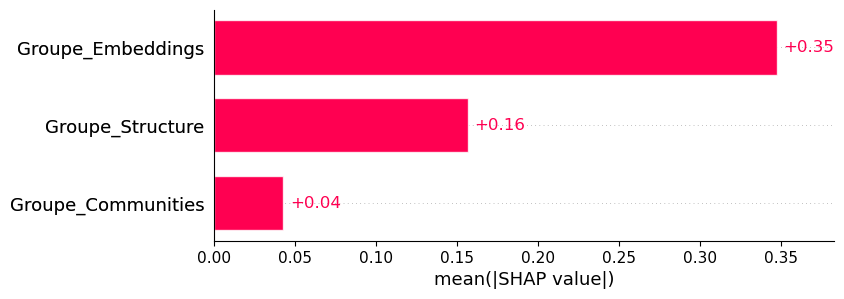


--- SHAP Custom Analysis ---


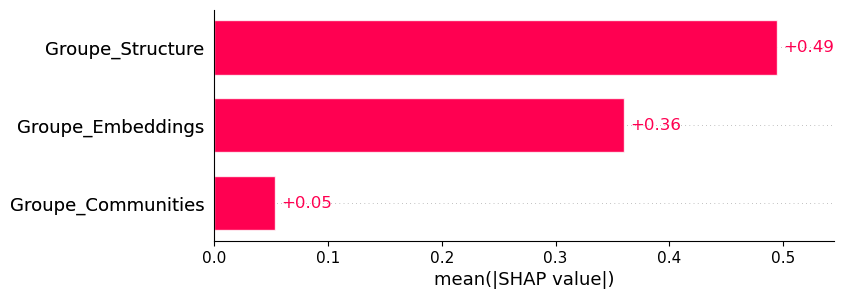


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


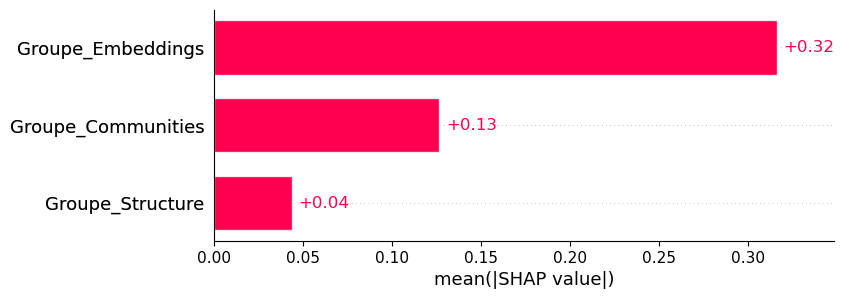


--- SHAP Bar Plot (Absolute) ---


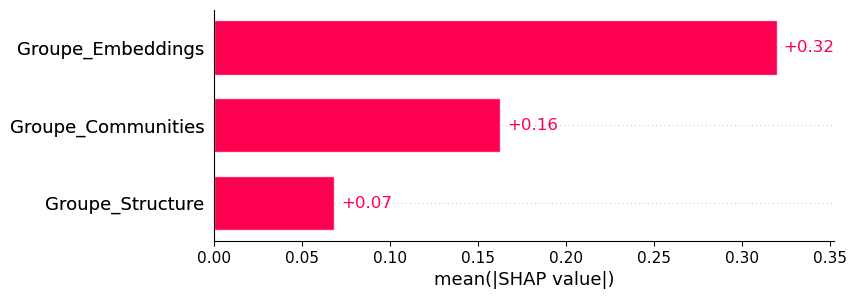


--- SHAP Custom Analysis ---


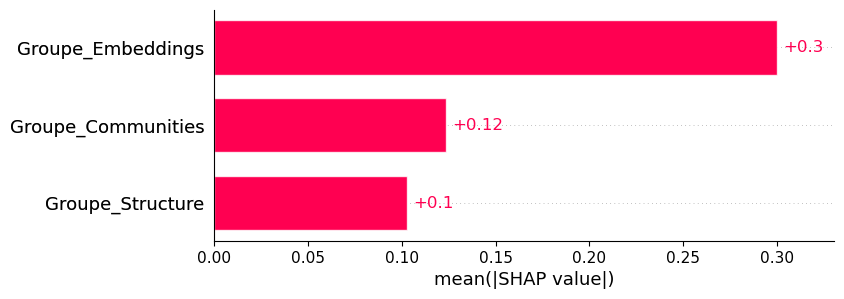


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
gp.evaluate("TEST_W_REAL_GROUPS_SBM_1", display = True)
gp.evaluate("TEST_W_REAL_GROUPS_SBM_0_5", display = True)

In [4]:
gp.display_shap("TEST_W_REAL_GROUPS_SBM_1")
gp.display_shap("TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib


1

In [30]:
dataset, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph("TEST_W_REAL_GROUPS_SBM_0_5")
dataset_base, xgboost_data_base, shap_explainer_base, shap_analysis_base = gp.load_all_data_for_graph("artificial_graph_sbm_0_50_pos_0_50")

gp.evaluate_model_performance(model = xgboost_data["model"], X_test = xgboost_data["X_test"], y_test = xgboost_data["y_test"], plot = False)
gp.evaluate_model_performance(model = xgboost_data_base["model"], X_test = xgboost_data_base["X_test"], y_test = xgboost_data_base["y_test"], plot = False)

print(dataset.head(2))
print(dataset_base.head(2))


dataset_cleared = dataset.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)
dataset_base_cleared = dataset_base.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)

print(dataset_cleared.head(2))
print(dataset_base_cleared.head(2))


all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_cleared)
all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_base)

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_TEST_W_REAL_GROUPS_SBM_0_5
 Taille : 6988 lignes, 23 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_50_pos_0_50
 Taille : 6988 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [43]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

all_results = []

for i in np.arange(0, 1.05, 0.05):
    
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    
    print(f"\n--- Évaluation : SBM {sbm_val} | POS {pos_val} ---")
    
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)

    print(dataset.columns)

    stats_df = gp.evaluate_model_performance(model=xgboost_data["model"], X_test=xgboost_data["X_test"], y_test=xgboost_data["y_test"], plot=False)
    
    all_results.append({
        "Graph_Name": G_name,
        "SBM_Ratio": i,
        "F1-Score": stats_df["F1-Score"].iloc[0]
    })

df_final_results = pd.DataFrame(all_results)

print("\n--- TABLEAU RÉCAPITULATIF ---")
print(df_final_results)

output_dir = os.path.join("outputs", "plots")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "artificial_graphs_recapitulatif_performances_f1.csv")

df_final_results.to_csv(output_path, index=False)

print(f"\n Tableau récapitulatif sauvegardé ici : {output_path}")


--- Évaluation : SBM 0.00 | POS 1.00 ---
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u',
       'community_v', 'same_community', 'infomap_u', 'infomap